Linear Reg Coef: 1.92
Poisson Reg Coef: 0.21


/Users/abrahambriones/Projects/modern_stats/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


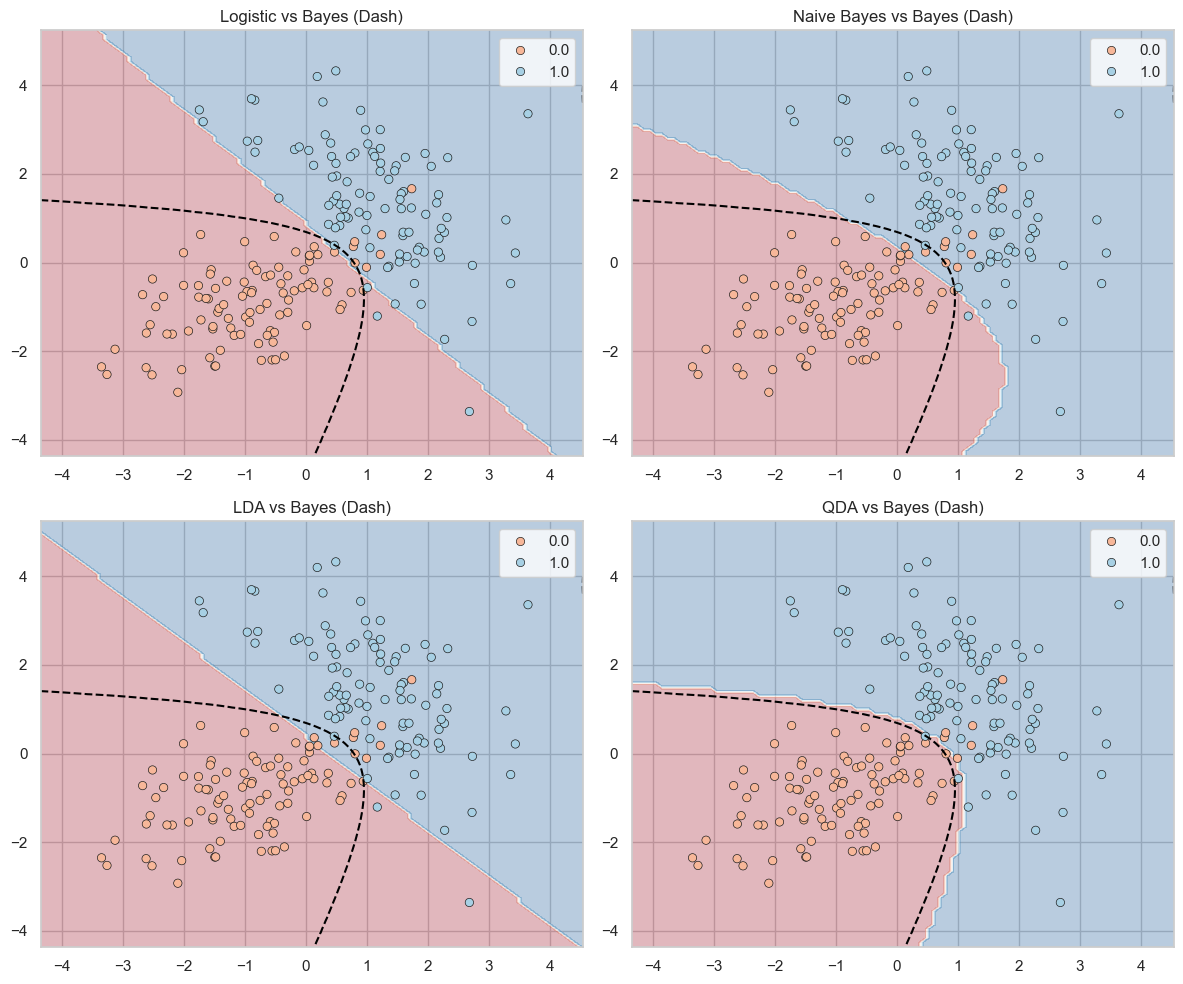

In [ ]:
"""
ML Expert Implementation: Modular Statistical Learning Suite.

1. Linear Regression: OLS estimation for continuous targets.
   - Business: Demand forecasting.
   - Social Science: Predicting life expectancy based on GDP.

2. Logistic Regression: Sigmoid-based classification.
   - Business: Marketing conversion attribution.
   - Social Science: Predicting probability of recidivism.

3. LDA: Linear decision boundaries assuming shared covariance.
   - Business: Customer segment classification.
   - Social Science: Identifying regional dialect groups from speech features.

4. QDA: Quadratic boundaries allowing class-specific covariance.
   - Business: High-frequency trading signal classification.
   - Social Science: Analyzing complex voting behaviors with interactions.

5. Naive Bayes: Probabilistic classification with independence assumptions.
   - Business: Automated document tagging.
   - Social Science: Content analysis of political speeches.

6. Poisson Regression: GLM for count-based data.
   - Business: Predicting weekly store foot traffic.
   - Social Science: Modeling frequency of historical conflicts.
"""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import multivariate_normal
from sklearn.linear_model import LinearRegression, LogisticRegression, PoissonRegressor
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB

# --- REGRESSION METHODS ---


def run_linear_regression(X: np.ndarray, y: np.ndarray) -> LinearRegression:
    """Standard OLS for continuous target variables."""
    model = LinearRegression()
    model.fit(X, y)
    return model


def run_poisson_regression(X: np.ndarray, y: np.ndarray) -> PoissonRegressor:
    """GLM for count data assuming Mean = Variance."""
    model = PoissonRegressor()
    model.fit(X, y)
    return model


# --- CLASSIFICATION METHODS ---


def run_logistic_regression(X: np.ndarray, y: np.ndarray) -> LogisticRegression:
    """Discriminative model for binary/multiclass probability."""
    model = LogisticRegression(penalty=None)
    model.fit(X, y)
    return model


def run_lda(X: np.ndarray, y: np.ndarray) -> LinearDiscriminantAnalysis:
    """Generative model assuming shared covariance across classes."""
    model = LinearDiscriminantAnalysis()
    model.fit(X, y)
    return model


def run_qda(X: np.ndarray, y: np.ndarray) -> QuadraticDiscriminantAnalysis:
    """Generative model allowing separate covariance per class."""
    model = QuadraticDiscriminantAnalysis()
    model.fit(X, y)
    return model


def run_naive_bayes(X: np.ndarray, y: np.ndarray) -> GaussianNB:
    """Generative model assuming feature independence."""
    model = GaussianNB()
    model.fit(X, y)
    return model


# --- VISUALIZATION & DATA GENERATION ---


def get_bayes_boundary(xx: np.ndarray, yy: np.ndarray, params: dict) -> np.ndarray:
    """Computes the theoretical optimal boundary."""
    grid = np.c_[xx.ravel(), yy.ravel()]
    p0 = multivariate_normal.pdf(grid, mean=params["m0"], cov=params["c0"])
    p1 = multivariate_normal.pdf(grid, mean=params["m1"], cov=params["c1"])
    return (p1 - p0).reshape(xx.shape)


def visualize_all():
    """Generates data and executes all methods for visual comparison."""
    # Synthetic Classification Data (Non-linear relationship)
    np.random.seed(42)
    m0, c0 = [-1, -1], [[1.5, 0.8], [0.8, 1.0]]
    m1, c1 = [1.2, 1.2], [[1.0, -0.6], [-0.6, 1.8]]
    params = {"m0": m0, "c0": c0, "m1": m1, "c1": c1}

    X_c0 = np.random.multivariate_normal(m0, c0, 100)
    X_c1 = np.random.multivariate_normal(m1, c1, 100)
    X_clf = np.vstack((X_c0, X_c1))
    y_clf = np.hstack((np.zeros(100), np.ones(100)))

    # Grid for boundaries
    h = 0.1
    x_min, x_max = X_clf[:, 0].min() - 1, X_clf[:, 0].max() + 1
    y_min, y_max = X_clf[:, 1].min() - 1, X_clf[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    grid_points = np.c_[xx.ravel(), yy.ravel()]

    bayes_z = get_bayes_boundary(xx, yy, params)

    # Dictionary of classifiers
    clf_models = {
        "Logistic": run_logistic_regression(X_clf, y_clf),
        "Naive Bayes": run_naive_bayes(X_clf, y_clf),
        "LDA": run_lda(X_clf, y_clf),
        "QDA": run_qda(X_clf, y_clf),
    }

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()

    for i, (name, model) in enumerate(clf_models.items()):
        # Decision Boundary
        Z = model.predict(grid_points).reshape(xx.shape)
        axes[i].contourf(xx, yy, Z, alpha=0.3, cmap="RdBu")
        # Bayes Boundary (Ground Truth)
        axes[i].contour(xx, yy, bayes_z, levels=[0], colors="black", linestyles="--")
        # Data points
        sns.scatterplot(
            x=X_clf[:, 0], y=X_clf[:, 1], hue=y_clf, ax=axes[i], palette="RdBu", edgecolor="k"
        )
        axes[i].set_title(f"{name} vs Bayes (Dash)")

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    # Regression demonstration (simple print check)
    X_reg = np.linspace(0, 10, 50).reshape(-1, 1)
    y_lin = 2 * X_reg.flatten() + np.random.normal(0, 2, 50)
    y_poi = np.random.poisson(lam=np.exp(0.2 * X_reg.flatten() + 1))

    lin_model = run_linear_regression(X_reg, y_lin)
    poi_model = run_poisson_regression(X_reg, y_poi)

    print(f"Linear Reg Coef: {lin_model.coef_[0]:.2f}")
    print(f"Poisson Reg Coef: {poi_model.coef_[0]:.2f}")

    visualize_all()